In [ ]:

%pip install lightkurve -q


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 92.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatib

In [ ]:
import lightkurve as lk
import numpy as np

/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [ ]:
# CELL 3
search = lk.search_lightcurve("Pi Mensae", author="SPOC", exptime=120)
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,261136679,0.0
1,TESS Sector 04,2018,SPOC,120,261136679,0.0
2,TESS Sector 08,2019,SPOC,120,261136679,0.0
3,TESS Sector 11,2019,SPOC,120,261136679,0.0
4,TESS Sector 12,2019,SPOC,120,261136679,0.0
5,TESS Sector 13,2019,SPOC,120,261136679,0.0
6,TESS Sector 27,2020,SPOC,120,261136679,0.0
7,TESS Sector 28,2020,SPOC,120,261136679,0.0
8,TESS Sector 31,2020,SPOC,120,261136679,0.0


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

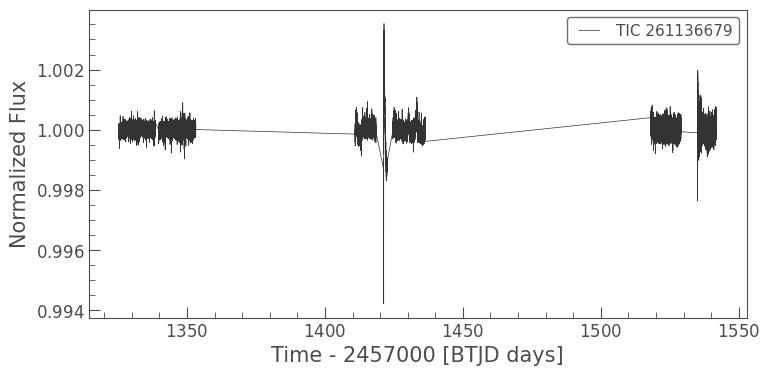

In [ ]:
# CELL 4
lc = search[0:3].download_all().stitch().remove_nans()
lc.plot()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

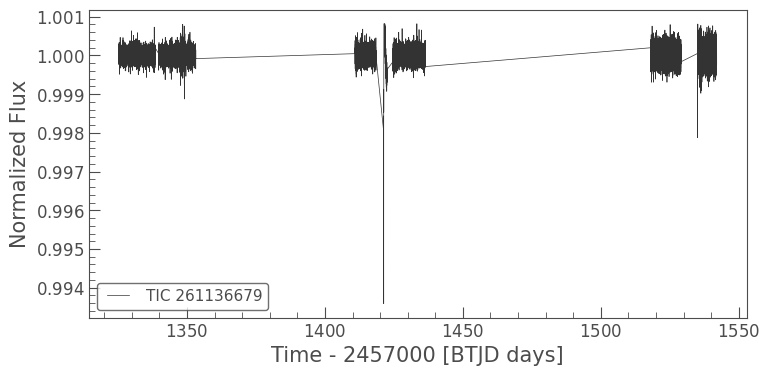

In [ ]:
# CELL 5
flat = lc.flatten(window_length=401)
flat = flat.remove_outliers(sigma_upper=4, sigma_lower=np.inf)
flat.plot()

<Axes: xlabel='Period [$\\mathrm{d}$]', ylabel='BLS Power'>

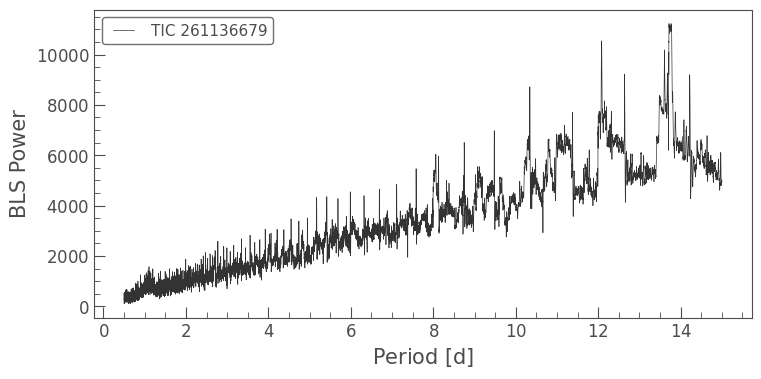

In [ ]:
# CELL 6
period_grid = np.linspace(0.5, 15, 20000)
bls = flat.to_periodogram(method="bls", period=period_grid, frequency_factor=500)
bls.plot()

In [ ]:
# CELL 7
planet_period = bls.period_at_max_power
planet_t0 = bls.transit_time_at_max_power
planet_depth = bls.depth_at_max_power
print(f"Best period: {planet_period:.4f}")
print(f"Depth: {planet_depth:.5f} ({planet_depth * 100:.3f} percent)")
print(f"Power score: {bls.max_power:.4f}")

Best period: 13.7167 d
Depth: 0.00094 (0.094 percent)
Power score: 11230.1160


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

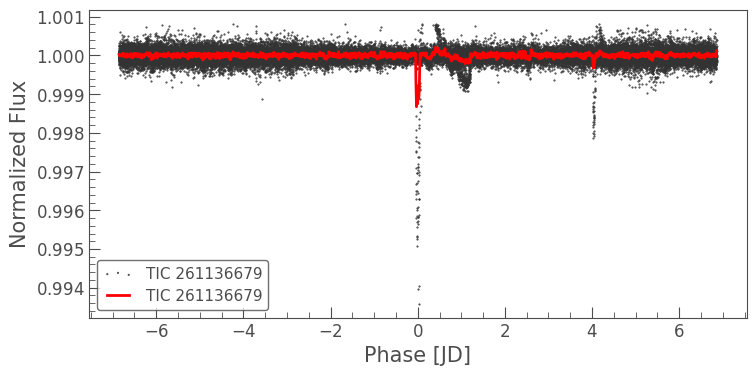

In [ ]:
# CELL 8
folded = flat.fold(period=planet_period, epoch_time=planet_t0)
ax = folded.scatter(s=1)
folded.bin(time_bin_size=10 / 60 / 24).plot(ax=ax, color="red", lw=2)

In [ ]:
def hunt(star, min_period=0.5, max_period=15):
    search = lk.search_lightcurve(star, author="SPOC", exptime=120)
    if len(search) == 0:
        search = lk.search_lightcurve(star, author="QLP")
    if len(search) == 0:
        print(f"No TESS data for {star}, try another star")
        return
    lc = search[0:3].download_all().stitch().remove_nans()
    flat = lc.flatten(window_length=401)
    flat = flat.remove_outliers(sigma_upper=4, sigma_lower=np.inf)
    grid = np.linspace(min_period, max_period, 20000)
    bls = flat.to_periodogram(method="bls", period=grid, frequency_factor=500)
    period = bls.period_at_max_power
    t0 = bls.transit_time_at_max_power
    depth = bls.depth_at_max_power
    print(f"Star: {star}  |  TIC: {lc.meta.get('TICID', 'see search table')}")
    print(f"Best period: {period:.4f}")
    print(f"Depth: {depth:.5f} ({depth * 100:.3f} percent)")
    print(f"Power score: {bls.max_power:.4f}")
    folded = flat.fold(period=period, epoch_time=t0)
    ax = folded.scatter(s=1)
    folded.bin(time_bin_size=10 / 60 / 24).plot(ax=ax, color="red", lw=2)

Star: HD 63433  |  TIC: 130181866
Best period: 7.1080 d
Depth: 0.00028 (0.028 percent)
Power score: 1179.2724


`period` contains 515234 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


Star: AU Mic  |  TIC: 441420236
Best period: 14.4627 d
Depth: 0.00275 (0.275 percent)
Power score: 11904.0285


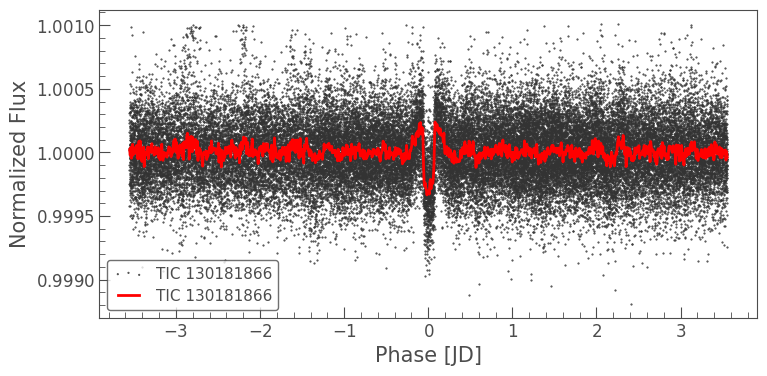

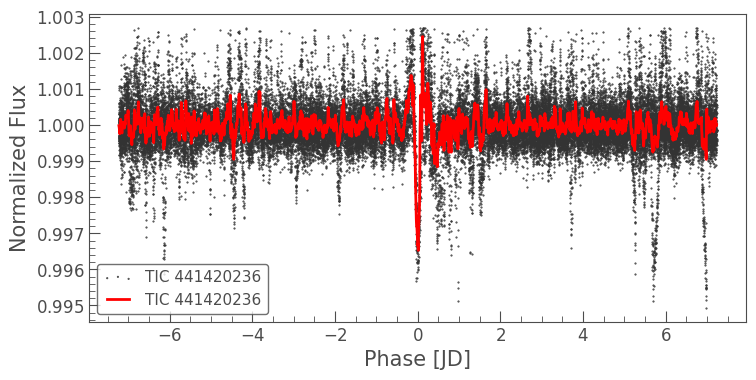

In [ ]:
hunt("HD 63433")
hunt("AU Mic")

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

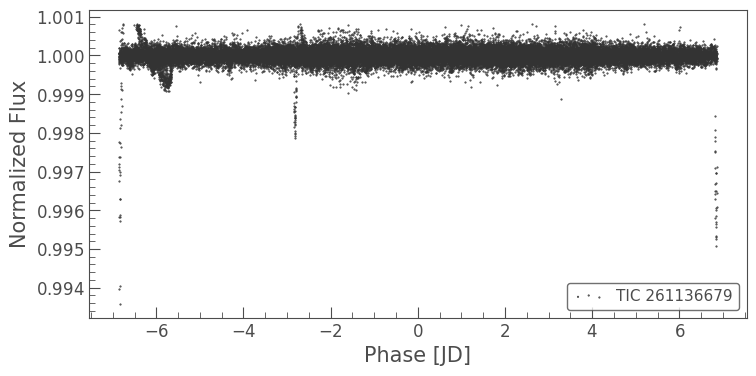

In [ ]:
# CELL 11
half = flat.fold(period=planet_period, epoch_time=planet_t0 + planet_period / 2)
half.scatter(s=1)

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

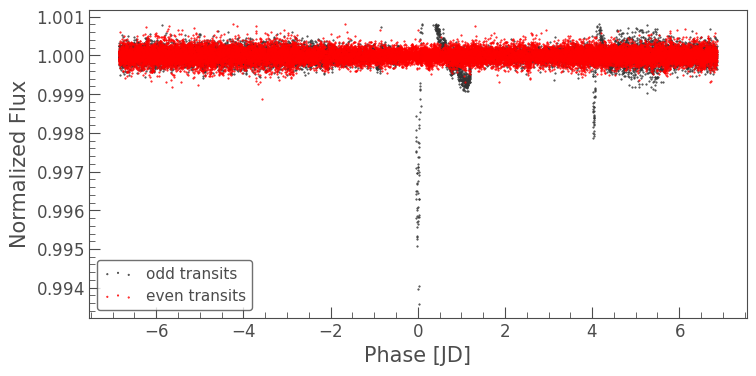

In [ ]:
# CELL 12
ax = folded[folded.odd_mask].scatter(s=1, label="odd transits")
folded[folded.even_mask].scatter(ax=ax, s=1, color="red", label="even transits")

In [ ]:
star_radius_suns = 1.1  # Replace with target star's radius in solar units from ExoFOP
planet_radius_suns = star_radius_suns * np.sqrt(planet_depth)
print(f"Planet radius: {planet_radius_suns * 109.2:.2f} Earths")
print(f"Planet radius: {planet_radius_suns * 9.95:.2f} Jupiters")

Planet radius: 3.68 Earths
Planet radius: 0.34 Jupiters
